# iSPy on the Drosophila pylorus — minimal reproduction of the spatial ploidy pipeline

**Paper:** Russell NJ, Belato PB, Oliver LS, Chakraborty A, Roeder AHK, Fox DT, Formosa-Jordan P.
*Spatial ploidy inference using quantitative imaging.* Cell Reports Methods 5(12):101249 (2025).
DOI: [10.1016/j.crmeth.2025.101249](https://doi.org/10.1016/j.crmeth.2025.101249)

**Code:** iSPy by Nicholas J. Russell, MIT license, pinned commit
[`8c2c51c3`](https://gitlab.gwdg.de/devplantpatterning/Publications/ispy-inferring-spatial-ploidy) (fetched at runtime from the GitLab API).

**Data:** Russell et al. OSF repository ([doi 10.17605/osf.io/um7r3](https://doi.org/10.17605/osf.io/um7r3)),
Drosophila child node [`wkaf5`](https://osf.io/wkaf5/): ilastik segmentation feature tables (CSV),
Object Identities (H5) and sum projections (TIF), one image per injury condition.

**Scope (partial demonstration).** We reproduce the core of the paper's **Figure 3** Drosophila
analysis: a pooled 2D Gaussian mixture model (normalized Hoechst intensity × projected nuclear
area, log2-scaled, 5 components) classifying segmented nuclei into ploidy classes, per-severity
class proportions, and a color-coded spatial ploidy map. We use **one image per injury condition**
(uninjured / mild / severe) instead of the paper's 17 pylori, so the numbers are a demonstration
of the method, not a reproduction of the published dataset-level statistics.

**Execution status:** executed notebook (CPU). All downloads and analysis run inside this notebook.

**Note:** this notebook drives the authors' pinned Python modules; the search/classification
cells re-implement the paper's stated hyperparameters verbatim (sklearn calls), and every
deviation from the author notebooks is stated next to the relevant cell.

**日本語:** このノートブックは論文 Figure 3 のコア（プールした 2D ガウス混合モデルによる ploidy 分類、
傷害度ごとのクラス比率、空間プロット）を、著者公開コード（commit 8c2c51c3）と OSF 公開データを用いて
最小構成で再現します。各傷害度から 1 枚の画像を使用する部分的なデモであり、論文のデータセット全体の
統計値の再現ではありません。CPU ランタイムで実行できます（GPU 不要）。


## 1. Runtime selection

**Select Runtime → Change runtime type → CPU (no GPU needed).** The iSPy pipeline is
pandas/scikit-learn/scipy CPU code; no GPU operation exists in the pinned author code. Expected
end-to-end time on a free Colab CPU runtime: roughly 10–20 minutes (downloads ≈ 25 MB, the 2D GMM
search with the authors' 500 initializations dominates). No interactive login or Drive mount is
required. Run all cells top to bottom.

**日本語:** GPU は不要です。「ランタイム → ランタイムのタイプを変更 → CPU」を選択してから
すべてのセルを実行してください。所要時間の目安は 10–20 分（ダウンロード約 25 MB、2D GMM の
探索が主な負荷）です。


In [ ]:
import importlib, sys, os, subprocess

def ensure(pkg, pipname=None):
    try:
        importlib.import_module(pkg)
        print(f"{pkg}: available")
    except ImportError:
        pipname = pipname or pkg
        print(f"{pkg}: installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pipname])

# Colab preinstalls numpy/pandas/scipy/sklearn/matplotlib/seaborn/h5py;
# tifffile is the only one sometimes missing.
for p in ["numpy", "pandas", "scipy", "sklearn", "matplotlib", "seaborn", "h5py", "tifffile"]:
    ensure(p)

import numpy, pandas, sklearn, matplotlib, scipy
print("python", sys.version.split()[0])
print("numpy", numpy.__version__, "| pandas", pandas.__version__,
      "| sklearn", sklearn.__version__, "| matplotlib", matplotlib.__version__)

os.chdir("/content")


numpy: available


pandas: available
scipy: available


sklearn: available
matplotlib: available


seaborn: available
h5py: available


tifffile: available
python 3.13.16
numpy 2.1.3 | pandas 2.2.3 | sklearn 1.6.1 | matplotlib 3.10.0


## 2. Fetch the pinned author code

We download the exact author modules (iSPy, MIT license) from the public GitLab API at the
**pinned commit `8c2c51c3`** into `/content/ispy`. Each file's byte size and SHA-256 are checked
against the values recorded from the same commit, so any tampering or truncation fails loudly.

**日本語:** 著者のコード（MIT ライセンス）を GitLab API から固定コミット `8c2c51c3` で取得し、
サイズと SHA-256 を検証します。


In [ ]:
import urllib.request, urllib.error, urllib.parse, hashlib, pathlib, time

COMMIT = "8c2c51c3"
RAW = "https://gitlab.gwdg.de/api/v4/projects/43478/repository/files/{0}/raw?ref=" + COMMIT

def fetch(url, expected_size=None, attempts=6):
    # bounded retry: OSF rate-limits shared Colab IPs (HTTP 429); honor Retry-After
    last = None
    for a in range(attempts):
        try:
            with urllib.request.urlopen(url, timeout=300) as r:
                data = r.read()
            if expected_size is not None and len(data) != expected_size:
                raise IOError(f"size {len(data)} != expected {expected_size}")
            return data
        except urllib.error.HTTPError as e:
            last = e
            if e.code in (429, 500, 502, 503) and a < attempts - 1:
                wait = int(e.headers.get("Retry-After", 20 * (a + 1)) or 20 * (a + 1))
                print(f"HTTP {e.code}; backing off {wait}s (attempt {a+1}/{attempts})")
                time.sleep(min(wait, 120))
            else:
                raise
    raise last

# (path, expected bytes, expected sha256) — recorded from commit 8c2c51c3 on 2026-10-06
AUTHOR_FILES = [
    ("tools/basics/Character_Class.py", 7086,
     "b2a6da97e9d38192ea074cc349eaf578e069aee115a84b718f143ef88787c478"),
    ("tools/basics/Plotting_Definitions_Class.py", 43056,
     "b77f329b55729c4b00c72ff0d8cd6baf7135000bec07ded78b8c9d3281400534"),
    ("tools/curve_fitting/Curve_Fitting_Plotting.py", 45768,
     "2849b9046c9ebabeda757c49ebd59baab50516331b6db5af0b26f50ae4eab23a"),
    ("tools/curve_fitting/Curve_Fitting_SKLearn.py", 15395,
     "853d5466651cc50dbffb9032641eac9bb63e81447e4cd990c4ee1dd0b8aace18"),
    ("tools/image_output/Image_Output.py", 16795,
     "f8bb0dceb6caa9f028e786fe6c29ff00f4683c4eb4c5b8f7af1204d23d39ba5a"),
]

ISPY = pathlib.Path("/content/ispy")
for rel, size, sha in AUTHOR_FILES:
    dest = ISPY / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists() or dest.stat().st_size != size:
        data = fetch(RAW.format(urllib.parse.quote(rel, safe="")), expected_size=size)
        assert hashlib.sha256(data).hexdigest() == sha, f"sha256 mismatch for {rel}"
        dest.write_bytes(data)
    assert hashlib.sha256(dest.read_bytes()).hexdigest() == sha
    print(f"verified {rel} ({size} B)")

# Author notebook uses '%matplotlib notebook' (not supported in Colab);
# the author's own comment offers '%matplotlib inline' as the alternative.
get_ipython().run_line_magic("matplotlib", "inline")
sys.path.insert(0, str(ISPY))

import tools.basics.Character_Class as Class
from tools.basics.Plotting_Definitions_Class import Plot, Normalize
from tools.curve_fitting.Curve_Fitting_Plotting import plot2DGaussianMixture
from tools.image_output.Image_Output import PredictionImage
print("author modules imported")

verified tools/basics/Character_Class.py (7086 B)


verified tools/basics/Plotting_Definitions_Class.py (43056 B)


verified tools/curve_fitting/Curve_Fitting_Plotting.py (45768 B)


verified tools/curve_fitting/Curve_Fitting_SKLearn.py (15395 B)


verified tools/image_output/Image_Output.py (16795 B)


author modules imported


## 3. Download the deposited Drosophila data (OSF, pinned links)

For each injury condition we take **Experiment 1, image 1**: the ilastik feature table
(`Data_Table_1.csv`), the Object Identities file (`Object_Identities_1.h5`, voxel→nucleus label
map used for the spatial output), the sum projection (`SUM_Projection_1.tif`, input preview), and
the haploid sperm control table (`Sperm_Data_Table_1.csv`) used by the paper to normalize Hoechst
intensity (STAR Methods). Files are fetched from their recorded OSF GUID download links and
checked against the recorded byte sizes.

**日本語:** 各傷害度について Experiment 1 の画像 1 枚分（分割特徴量 CSV、Object Identities H5、
和投影 TIF、正規化用精子 CSV）を OSF の固定リンクからダウンロードし、サイズを検証します。


In [ ]:
import urllib.request, pathlib, math

BASE = "https://osf.io/download/{0}/"

# condition -> (filename, expected bytes, GUID)   [recorded from api.osf.io metadata, 2026-10-06]
DATA_FILES = {
    "Uninjured": {
        "csv":   ("Data_Table_1.csv",         488131, "67bcb988f4a019f51ed4cce9"),
        "h5":    ("Object_Identities_1.h5",  4610296, "67bcb9870ec1e3dcc02debaa"),
        "tif":   ("SUM_Projection_1.tif",   2344091, "67bcb97d1816c0d9fb6cc7d0"),
        "sperm": ("Sperm_Data_Table_1.csv",   36836, "67bcb9a11816c0d9fb6cc7db"),
    },
    "Mild": {
        "csv":   ("Data_Table_1.csv",         310983, "67bc6d99569134832d709d81"),
        "h5":    ("Object_Identities_1.h5",  4610296, "67bc6d975b7df922b6d4c248"),
        "tif":   ("SUM_Projection_1.tif",   3145958, "s7akh"),  # legacy short GUID (api-verified)
        "sperm": ("Sperm_Data_Table_1.csv",   40333, "67bc705766d40a8086071f08"),
    },
    "Severe": {
        "csv":   ("Data_Table_1.csv",          39550, "67bc8c261a207b7af0d4c055"),
        "h5":    ("Object_Identities_1.h5",  4610296, "67bc8c2a5791ac8eab2deaa3"),
        "tif":   ("SUM_Projection_1.tif",   3145958, "67bc8bc74d446d3ef4071c88"),
        "sperm": ("Sperm_Data_Table_1.csv",   25555, "67bc8c302c261096d5d4c211"),
    },
}

DATA = pathlib.Path("/content/data")
CONDITIONS = list(DATA_FILES)
for cond, entries in DATA_FILES.items():
    (DATA / cond).mkdir(parents=True, exist_ok=True)
    for kind, (fname, size, guid) in entries.items():
        dest = DATA / cond / fname
        if not dest.exists() or dest.stat().st_size != size:
            blob = fetch(BASE.format(guid), expected_size=size)
            dest.write_bytes(blob)
            print(f"downloaded {cond}/{fname} ({len(blob):,} B)")
        print(f"{cond:10s} {fname:26s} {dest.stat().st_size:>9,d} B  OK")

# sanity: H5 and TIF must parse
import h5py, tifffile
for cond in CONDITIONS:
    with h5py.File(DATA / cond / "Object_Identities_1.h5", "r") as f:
        print(cond, "h5 keys:", list(f.keys()))
    im = tifffile.imread(DATA / cond / "SUM_Projection_1.tif")
    print(cond, "sum projection shape:", im.shape, im.dtype)

HTTP 429; backing off 20s (attempt 1/6)


downloaded Uninjured/Data_Table_1.csv (488,131 B)
Uninjured  Data_Table_1.csv             488,131 B  OK


HTTP 429; backing off 20s (attempt 1/6)


downloaded Uninjured/Object_Identities_1.h5 (4,610,296 B)
Uninjured  Object_Identities_1.h5     4,610,296 B  OK


downloaded Uninjured/SUM_Projection_1.tif (2,344,091 B)
Uninjured  SUM_Projection_1.tif       2,344,091 B  OK


...

downloaded Mild/Sperm_Data_Table_1.csv (40,333 B)
Mild       Sperm_Data_Table_1.csv        40,333 B  OK


downloaded Severe/Data_Table_1.csv (39,550 B)
Severe     Data_Table_1.csv              39,550 B  OK


downloaded Severe/Object_Identities_1.h5 (4,610,296 B)
Severe     Object_Identities_1.h5     4,610,296 B  OK


downloaded Severe/SUM_Projection_1.tif (3,145,958 B)
Severe     SUM_Projection_1.tif       3,145,958 B  OK


downloaded Severe/Sperm_Data_Table_1.csv (25,555 B)
Severe     Sperm_Data_Table_1.csv        25,555 B  OK
Uninjured h5 keys: ['exported_data']
Uninjured sum projection shape: (897, 871, 3) uint8
Mild h5 keys: ['exported_data']
Mild sum projection shape: (1024, 1024, 3) uint8
Severe h5 keys: ['exported_data']
Severe sum projection shape: (1024, 1024, 3) uint8


## 4. Inspect the feature tables and normalize Hoechst intensity (paper's rule)

The paper (STAR Methods, *Nuclear segmentation and data processing for Drosophila melanogaster*)
normalizes each pyloric nucleus' **Total Intensity** by the **median intensity of haploid
spermatids imaged on the same slide** (1C), so that 2^0 = 1C, 2^1 = 2C, 2^2 = 4C … Sperm
experiments were used only if ≥ 10 spermatids were present, the median was 2000–6000, and 90 %
of sperm intensities divided by the median lay in 0.5–1.5. Whether the deposited CSVs already
contain normalized intensities cannot be known from metadata alone, so this cell inspects the
actual columns and applies the paper's rule explicitly, printing every decision.

**日本語:** 論文の STAR Methods に従い、総 Hoescht 強度を同一スライドの精子（1C）の中央値で正規化します。
投入 CSV の列を実行時に確認し、正規化済みか生値かを判定してから適用します（判定内容は出力に表示）。


In [ ]:
import pandas as pd, numpy as np

INTENSITY_ALIASES = ["Total Intensity_0", "Total Intensity"]  # ilastik version dependent (paper)

def find_col(df, aliases):
    for a in aliases:
        if a in df.columns:
            return a
    return None

tables, decisions = {}, {}
for cond in CONDITIONS:
    df = pd.read_csv(DATA / cond / "Data_Table_1.csv")
    print(f"=== {cond}: {df.shape[0]} segmented objects ===")
    if "User Label" in df.columns:
        print("  User Label counts:", df["User Label"].value_counts().to_dict())
    if "Predicted Class" in df.columns:
        print("  Predicted Class counts:", df["Predicted Class"].value_counts().to_dict())
    # Paper (STAR Methods): for uninjured/mild pylori, incomplete/foreign nuclei were
    # hand-selected and REMOVED from quantification; the deposited 'User Label'
    # column marks those objects as 'Bad Nuclei'.
    if "User Label" in df.columns:
        bad = df["User Label"] == "Bad Nuclei"
        print(f"  -> excluding {int(bad.sum())} hand-marked 'Bad Nuclei' objects")
        df = df[~bad].reset_index(drop=True)
    tables[cond] = df
    print(f"  kept {len(df)} nuclei for analysis")

# decide the intensity column per condition
for cond in CONDITIONS:
    df = tables[cond]
    norm_col = next((c for c in df.columns if "normaliz" in c.lower() and "intens" in c.lower()), None)
    area_col = find_col(df, ["Size in pixels"])
    if norm_col is not None:
        src, how = norm_col, "deposited normalized column"
        df["Normalized Hoechst Intensity"] = df[norm_col].astype(float)
    else:
        raw_candidates = [c for c in df.columns if c.startswith("Total Intensity")]
        assert raw_candidates, f"no intensity column found in {cond}"
        # The paper: use the sperm (1C) channel whose statistics satisfy
        # n>=10, median 2000-6000, p90/median 0.5-1.5 — this identifies the Hoechst channel.
        sp = pd.read_csv(DATA / cond / "Sperm_Data_Table_1.csv")
        sp_candidates = [c for c in sp.columns if c.startswith("Total Intensity")]
        assert sp_candidates, f"no intensity column found in {cond} sperm table"
        report = []
        for c in sp_candidates:
            v = sp[c].astype(float).values
            n, med = len(v), np.median(v)
            r90 = np.percentile(v, 90) / med
            ok = n >= 10 and 2000 <= med <= 6000 and 0.5 <= r90 <= 1.5
            report.append((c, n, med, r90, ok))
        for c, n, med, r90, ok in report:
            print(f"[{cond}] sperm '{c}': n={n}, median={med:.0f}, p90/median={r90:.2f} "
                  f"-> paper criteria {'OK' if ok else 'FAIL'}")
        passing = [r for r in report if r[4]]
        if passing:
            chosen = passing[0][0]; sp_med = passing[0][2]; status = "criteria-satisfying channel"
        else:
            chosen = report[0][0]; sp_med = report[0][2]
            status = ("WARNING: no sperm channel satisfies all paper criteria; "
                      "using the first channel — deposited-control limitation")
        print(f"[{cond}] sperm channel selected: '{chosen}' ({status}), median={sp_med:.0f}")
        assert chosen in raw_candidates, f"{cond}: sperm channel {chosen} missing in pylorus table"
        df["Normalized Hoechst Intensity"] = df[chosen].astype(float) / sp_med
        src, how = chosen, f"'{chosen}' divided by same-slide sperm median ({sp_med:.0f})"
    assert area_col is not None, f"no 'Size in pixels' column in {cond}"
    med_log2 = np.log2(df["Normalized Hoechst Intensity"]).median()
    print(f"[{cond}] intensity source: {src} ({how})")
    print(f"[{cond}] median log2(normalized intensity) = {med_log2:.2f} "
          "(paper: 2C-16C nuclei should span ~1 to >=4)")
    decisions[cond] = how

# persist the filtered/normalized tables for the author pipeline
PROC = pathlib.Path("/content/ispy/data"); PROC.mkdir(parents=True, exist_ok=True)
CSV_FILES, LEGENDS = [], []
for cond in CONDITIONS:
    out = PROC / f"{cond.replace(' ', '_')}_normalized.csv"
    tables[cond].to_csv(out, index=False)
    CSV_FILES.append(str(out)); LEGENDS.append(cond)
print("normalized tables written:", CSV_FILES)

=== Uninjured: 770 segmented objects ===
  User Label counts: {'0': 579, 'Bad Nuclei': 191}
  Predicted Class counts: {'Bad Nuclei': 770}
  -> excluding 191 hand-marked 'Bad Nuclei' objects
  kept 579 nuclei for analysis
=== Mild: 482 segmented objects ===
  User Label counts: {'0': 347, 'Best Nuclei': 135}
  Predicted Class counts: {'Best Nuclei': 415, 'Bad Nuclei': 67}
  -> excluding 0 hand-marked 'Bad Nuclei' objects
  kept 482 nuclei for analysis
=== Severe: 58 segmented objects ===
  User Label counts: {'Bad Nuclei': 35, 'Best Nuclei': 22, '0': 1}
  Predicted Class counts: {'Bad Nuclei': 36, 'Best Nuclei': 22}
  -> excluding 35 hand-marked 'Bad Nuclei' objects
  kept 23 nuclei for analysis
[Uninjured] sperm 'Total Intensity_0': n=54, median=5910, p90/median=2.06 -> paper criteria FAIL
[Uninjured] sperm 'Total Intensity_1': n=54, median=5910, p90/median=2.06 -> paper criteria FAIL
[Uninjured] sperm 'Total Intensity_2': n=54, median=5910, p90/median=2.06 -> paper criteria FAIL
[Unin

### 4b. Check the Object-Identity column for the spatial output

The author code matches each CSV row to a voxel label in the Object Identities H5 through a
column given by `Column_ID_Label` (ilastik writes `labelimage_oid`). If the column is missing
the author code falls back to row order, which would silently mislabel the spatial map — so we
verify up front that every CSV `labelimage_oid` value occurs in the H5 label image, and record
the (optional) `User label` object column for reporting.

**日本語:** 空間出力に必要な `labelimage_oid` 列が H5 のラベル値と整合するかを事前に検証します
（列が無い場合、著者コードは行順を仮定して誤ラベルになるため明示的に確認します）。


In [ ]:
import h5py

def load_oid_image(path):
    with h5py.File(path, "r") as f:
        if "exported_data" in f:
            dset = f["exported_data"]
        else:
            keys = list(f.keys()); assert len(keys) == 1, f"ambiguous h5: {keys}"
            dset = f[keys[0]]
        arr = np.array(dset)
    if arr.ndim == 4:      # (1, H, W, 1) ilastik export
        arr = arr[0, :, :, 0]
    elif arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[:, :, 0]
    return arr

OID_COL, USER_COL = None, None
for cond in CONDITIONS:
    df = tables[cond]
    lab = load_oid_image(DATA / cond / "Object_Identities_1.h5")
    h5_labels = set(np.unique(lab).tolist()) - {0}
    cand = "labelimage_oid" if "labelimage_oid" in df.columns else None
    print(f"[{cond}] h5 labels: {len(h5_labels)} objects, image {lab.shape}")
    if cand:
        oids = set(df[cand].astype(int).tolist())
        missing = oids - h5_labels
        print(f"[{cond}] '{cand}' values: {len(oids)}, missing from h5: {len(missing)}")
        assert not missing, f"{cond}: OID values absent from H5 -> spatial map would be wrong"
        OID_COL = cand
    else:
        print(f"[{cond}] WARNING: no labelimage_oid column; author fallback would use row order")
    for c in df.columns:
        if "label" in c.lower() and df[c].dtype == object:
            print(f"[{cond}] {c} value counts:", df[c].value_counts().to_dict())
            USER_COL = USER_COL or c
print("Column_ID_Label =", OID_COL)

[Uninjured] h5 labels: 770 objects, image (897, 871)
[Uninjured] 'labelimage_oid' values: 579, missing from h5: 0
[Uninjured] User Label value counts: {'0': 579}
[Mild] h5 labels: 482 objects, image (1024, 1024)
[Mild] 'labelimage_oid' values: 482, missing from h5: 0
[Mild] User Label value counts: {'0': 347, 'Best Nuclei': 135}
[Severe] h5 labels: 58 objects, image (1024, 1024)
[Severe] 'labelimage_oid' values: 23, missing from h5: 0
[Severe] User Label value counts: {'Best Nuclei': 22, '0': 1}
Column_ID_Label = labelimage_oid


## 5. Input preview: sum projections with segmented nuclei

Before any analysis we display the actual inputs: the confocal sum projection of each pylorus
with the outlines of the segmented nuclei (from the Object Identities file) drawn on top. This
confirms that CSV rows, H5 labels and images belong together. Scale is in pixels (the ilastik
export does not record the microscope pixel size; ploidy classes are unaffected because they
depend on log2 ratios, not absolute calibration).

**日本語:** 解析前に各傷害度の和投影画像と、Object Identities から得た核の輪郭を重ねて表示し、
CSV・H5・画像の対応を確認します。


previews rendered


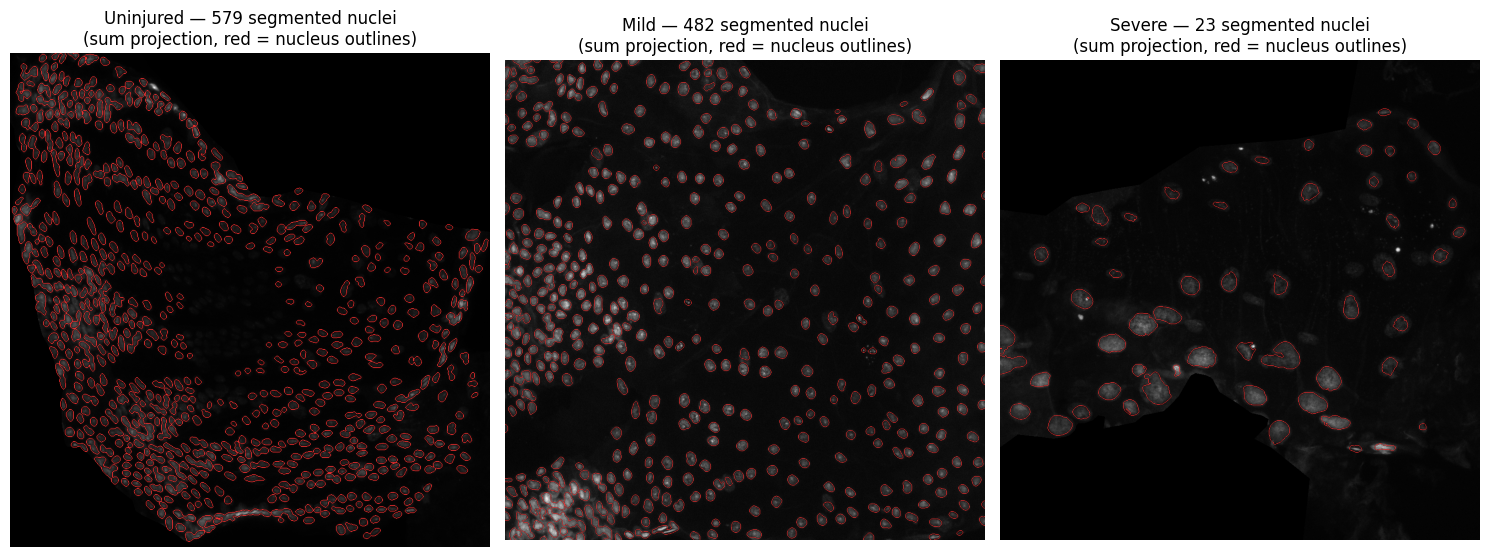

In [ ]:
import matplotlib.pyplot as plt

def outline_mask(labels):
    m = labels != 0
    b = np.zeros_like(m)
    b[1:, :] |= m[1:, :] != m[:-1, :]
    b[:-1, :] |= m[1:, :] != m[:-1, :]
    b[:, 1:] |= m[:, 1:] != m[:, :-1]
    b[:, :-1] |= m[:, 1:] != m[:, :-1]
    return b

fig, axes = plt.subplots(1, 3, figsize=(15, 6), tight_layout=True)
for ax, cond in zip(axes, CONDITIONS):
    im = tifffile.imread(DATA / cond / "SUM_Projection_1.tif").astype(float)
    im = (im - im.min()) / (np.ptp(im) + 1e-9)
    lab = load_oid_image(DATA / cond / "Object_Identities_1.h5")
    ax.imshow(im, cmap="gray")
    ob = outline_mask(lab)
    rgba = np.zeros(im.shape[:2] + (4,)); rgba[..., 0] = 0.15; rgba[..., 3] = 0
    rgba[ob] = [1.0, 0.2, 0.2, 0.9]
    ax.imshow(rgba)
    n_nuc = int(len(tables[cond]))
    ax.set_title(f"{cond} — {n_nuc} segmented nuclei\n(sum projection, red = nucleus outlines)")
    ax.axis("off")
print("previews rendered")

## 6. 1D GMM component selection (paper Figure S5 analogue, numeric table)

The paper first ran 1D Gaussian mixtures on each single feature and used AIC/BIC to choose the
number of ploidy classes (intensity: 6 by AIC / 2 by BIC; area: 5 by AIC / 4 by BIC; a
five-component 1D model was then focused on). We replicate that search numerically with the
paper's exact hyperparameters (tol 1e-5, max_iter 10000, 20 inits, k-means++) and print the AIC
and BIC for 1–6 components. This is a verbatim-method sklearn replication of the author's
`Fit_1DGaussianMix` search (author hyperparameters in
`tools/curve_fitting/Curve_Fitting_SKLearn.py`), presented as a table instead of ~20 figures.

**日本語:** 論文と同じハイパーパラメータで 1D GMM の成分数 1–6 を AIC/BIC で探索し、表として
表示します（著者コードの探索処理の数値再現、図は省略）。


In [ ]:
from sklearn.mixture import GaussianMixture

def pooled_log2(col):
    x = np.concatenate([tables[c][col].astype(float).values for c in CONDITIONS])
    return np.log2(x).reshape(-1, 1)

def search_1d(x, kmin=1, kmax=6):
    rows = []
    for k in range(kmin, kmax + 1):
        m = GaussianMixture(k, covariance_type="diag", tol=1e-5, max_iter=10000,
                            n_init=20, init_params="k-means++", random_state=0).fit(x)
        rows.append((k, m.aic(x), m.bic(x)))
    return pd.DataFrame(rows, columns=["components", "AIC", "BIC"]).set_index("components")

x_int = pooled_log2("Normalized Hoechst Intensity")
x_area = pooled_log2("Size in pixels")  # pixels; linear voxel scale cancels in log2 class ratios
print("1D search — Normalized Hoechst Intensity (n=%d nuclei):" % len(x_int))
display(search_1d(x_int))
print("1D search — projected nuclear area, 'Size in pixels':")
display(search_1d(x_area))
print("Paper (Fig. S5): intensity 6 comps (AIC) / 2 (BIC); area 5 (AIC) / 4 (BIC).")

1D search — Normalized Hoechst Intensity (n=1084 nuclei):


,AIC,BIC
components,,
1,3929.784830,3939.761657
2,3681.778408,3706.720474
3,3515.384585,3555.291891
4,3470.621128,3525.493673
5,3466.378608,3536.216393
6,3469.286322,3554.089346


1D search — projected nuclear area, 'Size in pixels':


,AIC,BIC
components,,
1,2658.058507,2668.035334
2,2582.817811,2607.759876
3,2494.743236,2534.650541
4,2477.977470,2532.850015
5,2482.589881,2552.427666
6,2486.262447,2571.065472


Paper (Fig. S5): intensity 6 comps (AIC) / 2 (BIC); area 5 (AIC) / 4 (BIC).


## 7. 2D Gaussian mixture: the paper's search, then classification

Following the paper: **log2-scale both features**, search **1–5 components × 4 covariance types**
with the authors' exact hyperparameters (tol 1e-7, max_iter 5000, **n_init 500**, k-means++),
select the best fit by AIC and BIC (the paper reports both criteria chose 5 components), then
classify every nucleus with `predict` and order classes 1…K from lowest to highest combined
mean (the author's ordering rule, copied verbatim from
`tools/curve_fitting/Curve_Fitting_Plotting.py::plot2DGaussianMixture`). The predictions are
registered in the author's `Char1.df_object` under the author's column naming
(`2D_N_<K>_Cov_<cov>`), so the author's own plotting/image-output functions can consume them.
The only deviation: `random_state=0` is set for a deterministic notebook.

**日本語:** 論文どおり log2 変換した 2 特徴量に対して 1–5 成分 × 4 種の共分散で AIC/BIC 探索
（著者のハイパーパラメータ）を行い、最良モデルで分類します。クラス順序付けは著者コードの
規則をそのまま使用します。


In [ ]:
XT = np.hstack([x_int, x_area])
N_RANGE, COV_TYPES = range(1, 6), ["spherical", "tied", "diag", "full"]

rows, models = [], {}
for cov in COV_TYPES:
    for k in N_RANGE:
        m = GaussianMixture(k, covariance_type=cov, tol=1e-7, max_iter=5000,
                            n_init=500, init_params="k-means++", random_state=0).fit(XT)
        models[(cov, k)] = m
        rows.append((cov, k, m.aic(XT), m.bic(XT)))
search2d = pd.DataFrame(rows, columns=["covariance", "components", "AIC", "BIC"])
display(search2d)

best_aic = search2d.loc[search2d.AIC.idxmin()]
best_bic = search2d.loc[search2d.BIC.idxmin()]
print("Best by AIC:", dict(best_aic))
print("Best by BIC:", dict(best_bic))
if int(best_aic.components) != int(best_bic.components):
    print("WARNING: AIC and BIC disagree on K; using the BIC optimum.")
BEST_K = int(best_bic.components); BEST_COV = str(best_bic.covariance)
print(f"Selected 2D model: K={BEST_K}, covariance={BEST_COV} "
      f"(paper: K=5; Fig. 3C shows diagonal covariance)")

# author's class ordering rule (verbatim from plot2DGaussianMixture)
best = models[(BEST_COV, BEST_K)]
Predict = best.predict(XT)
Uniq = np.unique(Predict)
Averages = np.zeros(len(Uniq))
for j in range(len(Uniq)):
    Where = np.where(Predict == Uniq[j])
    Averages[j] = (np.mean(2.0 ** XT[Where, 0]) ** 2 + np.mean(2.0 ** XT[Where, 1]) ** 2)
Ordered = np.argsort(Averages)
PredOrder = np.zeros(len(Predict))
for j in range(len(Uniq)):
    Where = np.where(Predict == Uniq[j])
    PredOrder[Where] = np.where(Ordered == j)[0] + 1

STR2D = f"2D_N_{BEST_K}_Cov_{BEST_COV}"
print("class counts:", np.bincount(PredOrder.astype(int))[1:])

,covariance,components,AIC,BIC
0,spherical,1,6939.222017,6954.187257
1,spherical,2,5434.399844,5469.318736
2,spherical,3,4914.362618,4969.235163
3,spherical,4,4624.914640,4699.740838
4,spherical,5,4343.823168,4438.603018
5,tied,1,4681.749128,4706.691194
6,tied,2,4687.749128,4727.656434
7,tied,3,4693.749125,4748.621670
8,tied,4,4699.749112,4769.586897
9,tied,5,4705.749097,4790.552121


Best by AIC: {'covariance': 'full', 'components': np.int64(5), 'AIC': np.float64(3909.9745402701806), 'BIC': np.float64(4054.6385225481686)}
Best by BIC: {'covariance': 'full', 'components': np.int64(5), 'AIC': np.float64(3909.9745402701806), 'BIC': np.float64(4054.6385225481686)}
Selected 2D model: K=5, covariance=full (paper: K=5; Fig. 3C shows diagonal covariance)
class counts: [256 147 233 390  58]


## 8. Build the author's result structures (joint scatter + histograms)

We now instantiate the author's `Characteristic` objects and run the author's `Plot` function
(`tools/basics/Plotting_Definitions_Class.py`) on the pooled, normalized tables. This produces
the paper-Figure-3B-style joint scatterplot of normalized Hoechst intensity vs projected nuclear
area with marginal histograms, and — importantly — fills `Char1.df_object` with the per-nucleus
`Object ID`, feature values and per-file legend needed by the spatial-output code. Parameter
notes: `Column_ID_Label` is set explicitly (the shipped `Two_Characteristics.ipynb` omits this
required argument — see the repository README); voxel sizes are 1 because `Size in pixels` is
already the projected area in pixels; thresholds are off (the deposited tables are the authors'
curated selections).

**日本語:** 著者の `Characteristic`／`Plot` を用いて特徴量オブジェクトと Figure 3B 相当の
散布図＋ヒストグラムを作成し、空間出力に必要な `df_object` を整えます。


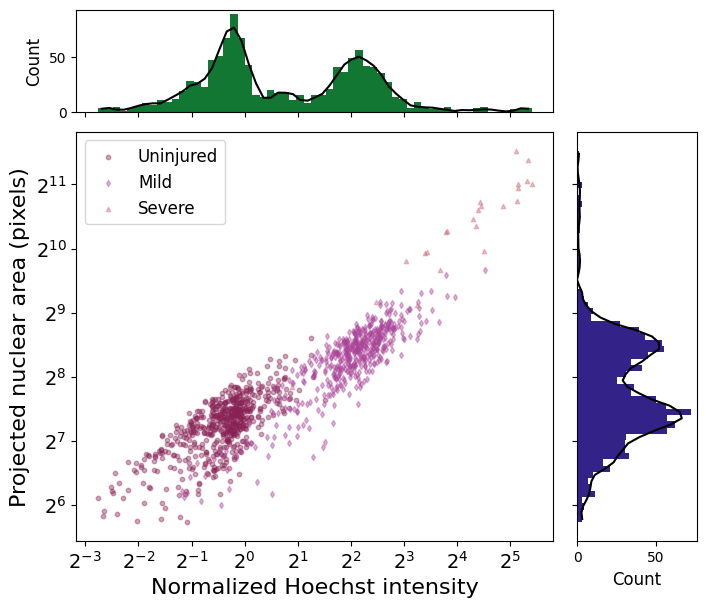

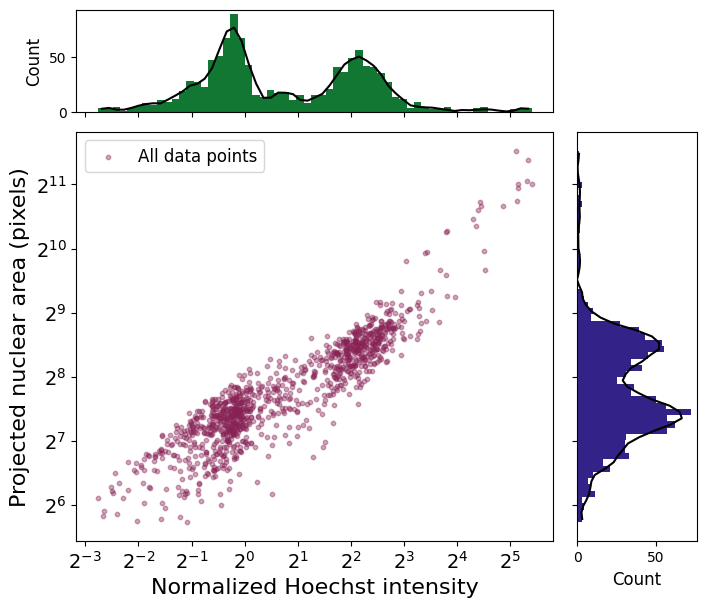

df_object: (1084, 4) | Files column: {'Uninjured': 579, 'Mild': 482, 'Severe': 23}


In [ ]:
os.chdir("/content/ispy")
for d in ["Results/ispy_colab_drosophila/Data",
          "Results/ispy_colab_drosophila/Curve_Fitting/Both_Chars/Plots",
          "Results/ispy_colab_drosophila/Curve_Fitting/Both_Chars/Data"]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)

Char1 = Class.Characteristic("Normalized Hoechst Intensity", "None", 5, "Log", 2,
                             "Number", 60, "Normalized Hoechst intensity", False, 1,
                             0, 0, 0, 0, [], OID_COL or "")
Char2 = Class.Characteristic("Size in pixels", "None", 5, "Log", 2,
                             "Number", 60, "Projected nuclear area (pixels)", False, 2,
                             0, 0, 0, 0, [], OID_COL or "")
PlotScheme = Class.Plotting(
    ["#882255", "#AA4499", "#CC6677", "#DDCC77", "#88CCEE", "#44AA99", "#117733", "#332288"],
    [], "Set3", ["o", "d", "^"], 10,
    indvplot=0, AIC=1, BIC=1, save_data=1, readme=1,
    pngs=0, pdfs=0, svgs=0, dark=0, exp_str="ispy_colab_drosophila",
    object=0, object_name="")

Plot(CSV_FILES, LEGENDS, Char1, Char2, 2, [1, 1, 1], PlotScheme)
print("df_object:", Char1.df_object.shape, "| Files column:",
      Char1.df_object["Files"].value_counts().to_dict())

## 9. Pooled 2D GMM result plots (author plotting functions)

We call the author's `plot2DGaussianMixture` once with the selected model. It renders (a) the
classified scatter in the log2 feature space (paper Figure 3C analogue) and (b) the proportion
of nuclei per ploidy class, and it writes the class means/medians to the run's ReadMe file —
all with the authors' own code.

**日本語:** 著者の `plot2DGaussianMixture` を用いて、分類結果の散布図（Figure 3C 相当）と
クラス比率図を描画します。


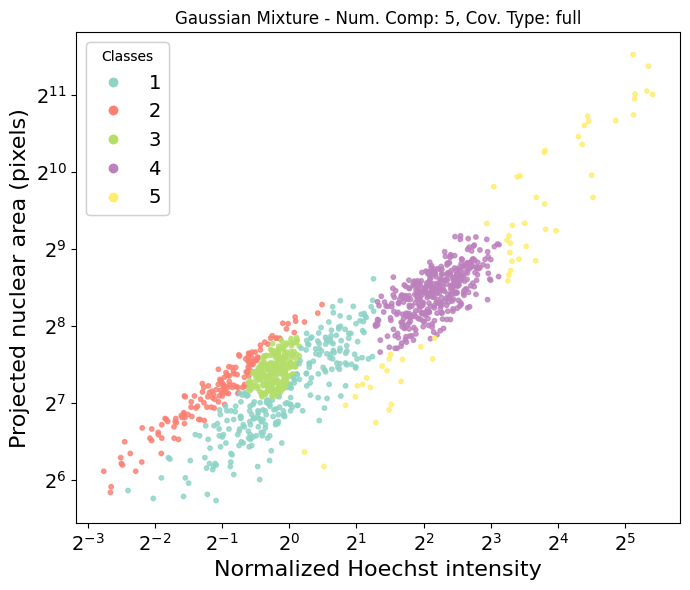

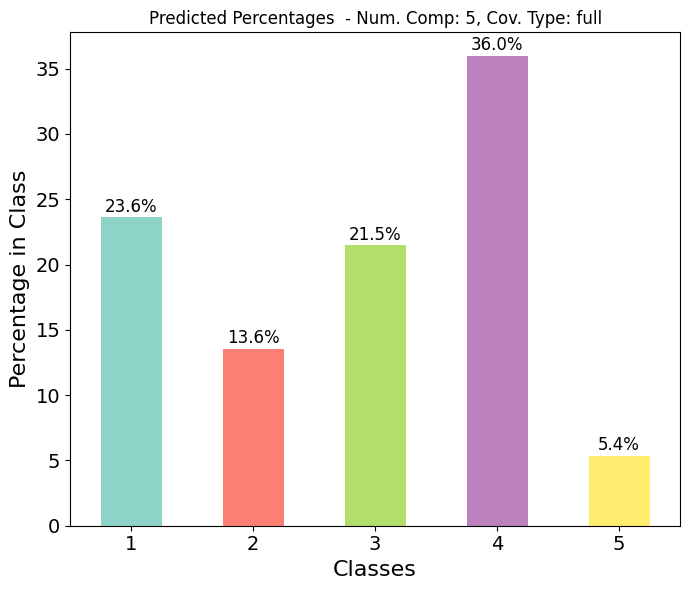

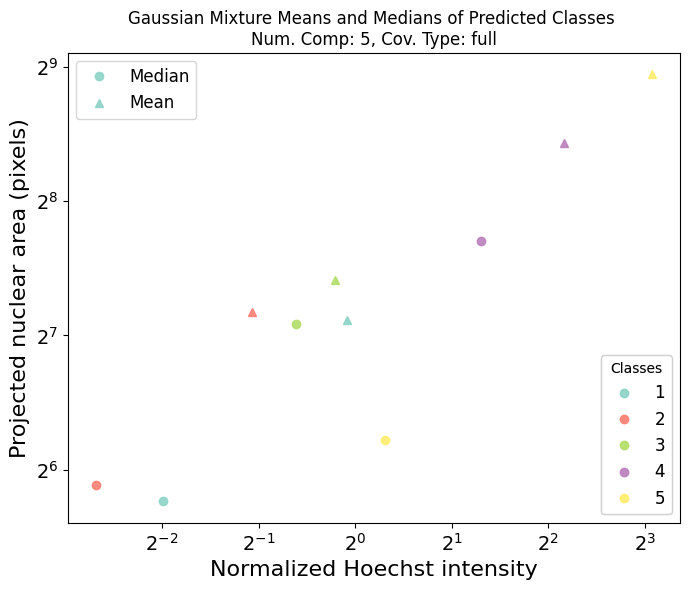

In [ ]:
NewDir = "./Results/ispy_colab_drosophila/Curve_Fitting/Both_Chars/Plots"
_ = plot2DGaussianMixture(XT, Predict, Char1, Char2, PlotScheme,
                          NewDir, BEST_COV, BEST_K)

## 10. Ploidy class proportions by injury severity (paper Figure 3D analogue)

From the pooled classification we tabulate the fraction of nuclei in each ploidy class per
condition and draw a grouped bar chart. **This chart is an additional visualization created for
this notebook** from the selected one-image-per-condition sample; the paper's Figure 3D is based
on 17 pylori. Expected qualitative pattern from the paper: uninjured nuclei dominated by 2C
(class 2), mildly injured by 4C (class 3), severely injured by ≥16C (class 5).

**日本語:** プールした分類結果から傷害度ごとのクラス比率を表と棒グラフ（本ノートブック独自の
追加可視化）にまとめます。論文の期待値は「無傷 2C、軽傷 4C、重傷 ≥16C が優勢」です。


2D_N_5_Cov_full,1.0,2.0,3.0,4.0,5.0
Files,,,,,
Mild,12.0,0.0,0.0,80.5,7.5
Severe,4.3,0.0,0.0,4.3,91.3
Uninjured,34.0,25.4,40.2,0.2,0.2


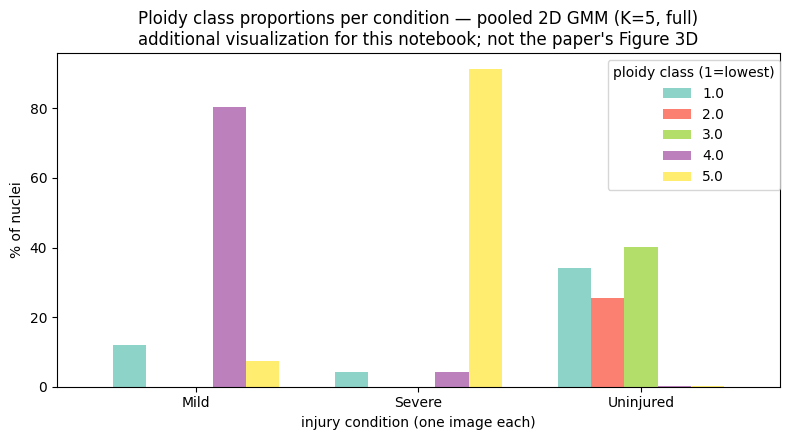

In [ ]:
prop = (Char1.df_object.groupby(["Files", STR2D]).size().unstack(fill_value=0)
        .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100).round(1))
display(prop)
prop.to_csv("./Results/ispy_colab_drosophila/per_condition_ploidy_proportions.csv")

K = BEST_K
colors = plt.get_cmap(PlotScheme.cmap)(np.linspace(0, 1, K))
fig, ax = plt.subplots(figsize=(8, 4.5), tight_layout=True)
prop.plot.bar(ax=ax, color=colors, width=0.75)
ax.set_ylabel("% of nuclei")
ax.set_xlabel("injury condition (one image each)")
ax.set_title(f"Ploidy class proportions per condition — pooled 2D GMM (K={BEST_K}, {BEST_COV})\n"
             "additional visualization for this notebook; not the paper's Figure 3D")
ax.legend(title="ploidy class (1=lowest)", bbox_to_anchor=(1.01, 1))
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

## 11. Spatial ploidy maps (paper Figure 3F analogue)

We run the authors' `PredictionImage` (`tools/image_output/Image_Output.py`) on the three Object
Identities files: every segmented nucleus is filled with its predicted ploidy class color and a
maximal-projection PNG is displayed. Class 0 (background) is unsegmented tissue.

**日本語:** 著者の `PredictionImage` を実行し、核を予測 ploidy クラスの色で塗った空間マップ
（Figure 3F 相当）を作成します。


prediction images rendered


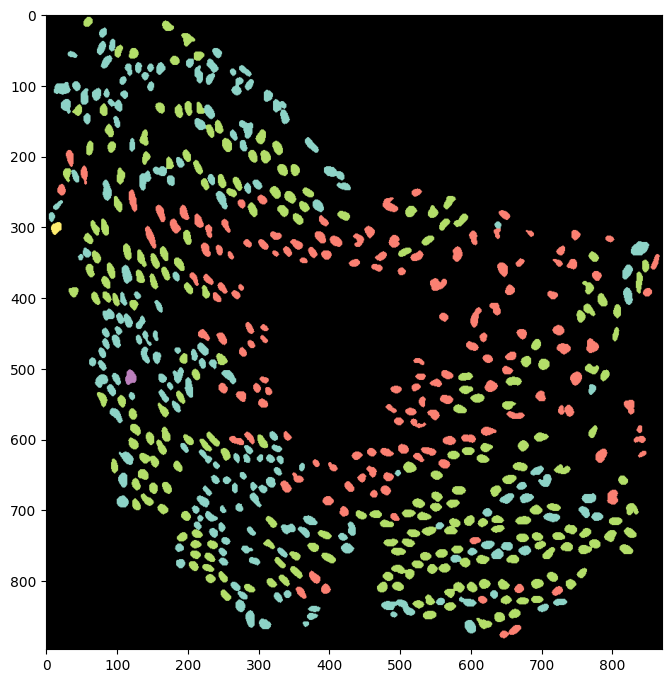

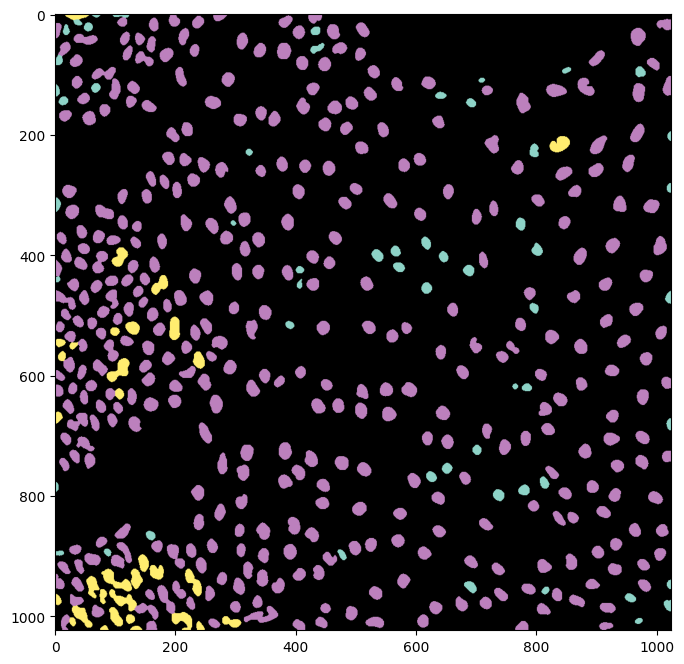

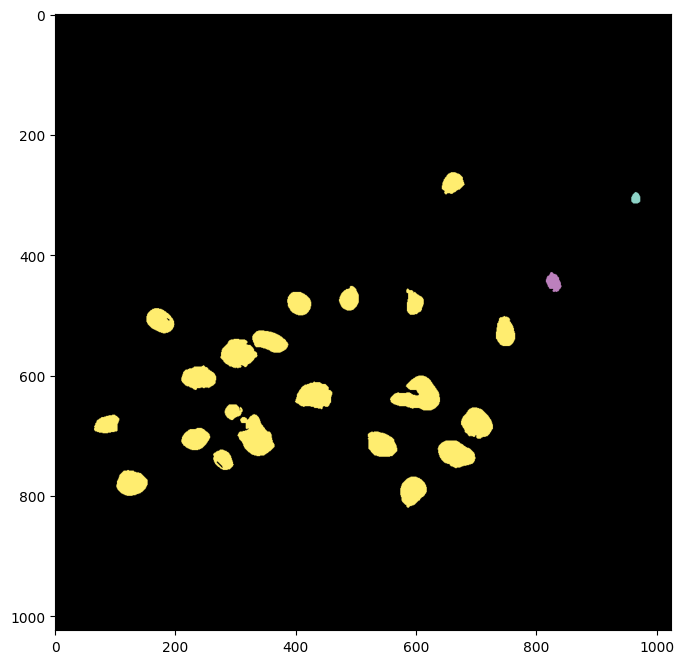

In [ ]:
PredictionImage([str(DATA / c / "Object_Identities_1.h5") for c in CONDITIONS],
                OID_COL or "", PlotScheme, Char1, Char2, 2, [1, 1, 1], 0)
print("prediction images rendered")

## 12. Input vs. prediction overlay

For a direct visual check we overlay the predicted ploidy classes (semi-transparent, `Set3`
colors) on the original sum projections. This is a notebook-specific rendering on top of the
authors' raw inputs; the author-produced colored segmentation is shown by the previous cell.

**日本語:** 元の和投影画像に予測クラスを半透明で重ねて確認します（著者コードの出力の上書きでは
なく追加表示）。


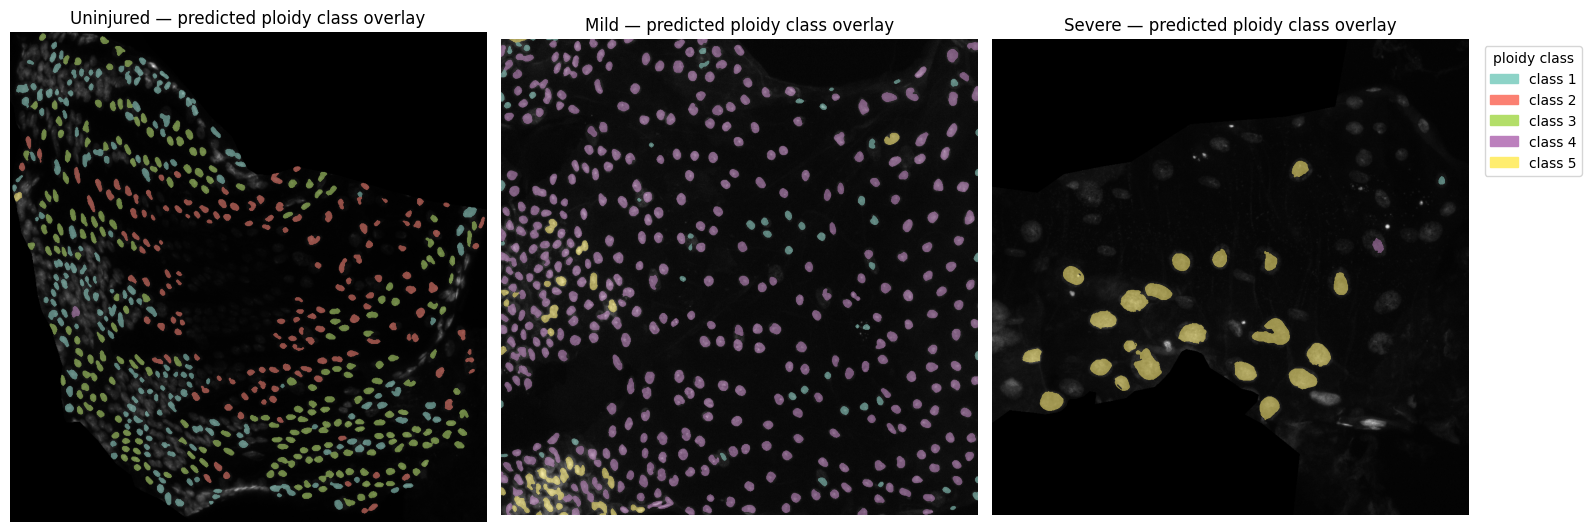

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), tight_layout=True)
cmap_colors = plt.get_cmap(PlotScheme.cmap)(np.linspace(0, 1, BEST_K))
for ax, cond in zip(axes, CONDITIONS):
    im = tifffile.imread(DATA / cond / "SUM_Projection_1.tif").astype(float)
    im = (im - im.min()) / (np.ptp(im) + 1e-9)
    ax.imshow(im, cmap="gray")
    sub = Char1.df_object[Char1.df_object["Files"] == cond]
    lab = load_oid_image(DATA / cond / "Object_Identities_1.h5")
    ov = np.zeros(lab.shape + (4,))
    for _, row in sub.iterrows():
        m = lab == int(row["Object ID"])
        cls = int(row[STR2D])
        ov[m] = [cmap_colors[cls - 1][0], cmap_colors[cls - 1][1], cmap_colors[cls - 1][2], 0.55]
    ax.imshow(ov)
    ax.set_title(f"{cond} — predicted ploidy class overlay")
    ax.axis("off")
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=cmap_colors[i], label=f"class {i+1}") for i in range(BEST_K)]
axes[-1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), title="ploidy class")
plt.show()

## 13. Interpretation, fold-increase check, limitations

The class means printed below should increase roughly **2-fold per class** in normalized Hoechst
intensity (the paper reports 1.8–2.0×) and ~1.6–1.7× in projected area, and the proportion table
should show the severity trend (uninjured ≈ 2C, mild ≈ 4C, severe ≥ 16C dominance). A
one-image-per-condition demo cannot validate the paper's dataset-level statistics.

**Limitations.** (i) One image per condition instead of the paper's 17 pylori; (ii) if the
deposited tables were already normalized, the sperm re-normalization is skipped by the decision
logic (see §4 output); (iii) absolute areas are in pixels because ilastik exports do not record
the pixel size (ratios and classes are unaffected); (iv) GMM results carry a small run-to-run
seed dependence (fixed here with `random_state=0`, which the author code leaves free).

**日本語:** クラス平均の強度は各クラスで約 2 倍増、面積は約 1.6–1.7 倍増、比率は
「無傷 2C／軽傷 4C／重傷 ≥16C」の傾向が期待されます。各条件 1 枚のデモであるため、
論文のデータセット規模の統計は検証できません。


In [ ]:
stat = (Char1.df_object.groupby(STR2D)
        .agg(mean_intensity=(Char1.label, "mean"),
             mean_area_px=(Char2.label, "mean")))
stat["intensity_fold_increase"] = stat["mean_intensity"] / stat["mean_intensity"].shift(1)
stat["area_fold_increase"] = stat["mean_area_px"] / stat["mean_area_px"].shift(1)
display(stat.round(2))
print("Paper (Drosophila): intensity fold increase 1.8-2.0x; area 1.6-1.7x per class.")

,mean_intensity,mean_area_px,intensity_fold_increase,area_fold_increase
2D_N_5_Cov_full,,,,
1.0,1.08,151.39,NaN,NaN
2.0,0.52,152.18,0.49,1.01
3.0,0.87,172.19,1.66,1.13
4.0,4.67,354.01,5.37,2.06
5.0,12.95,775.97,2.77,2.19


Paper (Drosophila): intensity fold increase 1.8-2.0x; area 1.6-1.7x per class.


## 14. References and provenance

- Paper: Russell et al., *Cell Reports Methods* 5(12):101249 (2025), DOI 10.1016/j.crmeth.2025.101249.
- Code: iSPy, MIT License © 2025 Nicholas Russell — GitLab
  `devplantpatterning/Publications/ispy-inferring-spatial-ploidy`, commit `8c2c51c3`
  (SHA-256-verified in §2). Files used: `Character_Class.py`, `Plotting_Definitions_Class.py`,
  `Curve_Fitting_Plotting.py`, `Curve_Fitting_SKLearn.py`, `Image_Output.py`.
- Data: Russell et al. OSF `doi:10.17605/osf.io/um7r3`, Drosophila node `wkaf5`
  (GUID-pinned downloads in §3, sizes verified at runtime).
- Method parameters: STAR Methods "Gaussian mixture models" (1D: tol 1e-5, 10000 iters, 20
  inits; 2D: tol 1e-7, 5000 iters, 500 inits, k-means++) and "Nuclear segmentation and data
  processing for Drosophila melanogaster" (spermatid normalization).
- This notebook was prepared as an independent reproduction exercise; the PhenoPaper
  investigation record was used as research guidance only, and all scientific parameters above
  were verified against the paper PDF and the pinned author code.

**日本語:** 出典は上記のとおりです。著者コード・データは固定バージョンから取得し、検証済みです。
